In [23]:
import zipfile
import os

with zipfile.ZipFile('/content/zomato.csv.zip', 'r') as zip_ref:
    zip_ref.extractall('/content')

print(os.listdir('/content'))

['.config', 'zomato.csv.zip', 'zomato.csv', 'sample_data']


In [24]:
import pandas as pd

df = pd.read_csv('/content/zomato.csv')

df.head()

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet


Zomato Restaurant Data Analysis

Objective:
The objective of this project is to analyze the Zomato restaurant dataset to identify customer preferences, popular cuisines, restaurant hotspots, pricing patterns, and factors influencing restaurant ratings. The analysis includes data cleaning, exploratory data analysis (EDA), visualizations, and business recommendations for an Alfido Tech–style platform.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from wordcloud import WordCloud
import seaborn as sns

plt.style.use("ggplot")

In [26]:
df = pd.read_csv('/content/zomato.csv')

df.head()

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet


In [27]:
print("Shape of Dataset:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Shape of Dataset: (56252, 13)

Columns:
Index(['address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'listed_in(type)'],
      dtype='object')

Data Types:
address                        object
name                           object
online_order                   object
book_table                     object
rate                           object
votes                          object
phone                          object
location                       object
rest_type                      object
dish_liked                     object
cuisines                       object
approx_cost(for two people)    object
listed_in(type)                object
dtype: object


In [28]:
missing = df.isnull().sum()

missing[missing > 0]

,0
address,17
name,16
online_order,19
book_table,58
rate,7838
votes,78
phone,1296
location,126
rest_type,338
dish_liked,28225


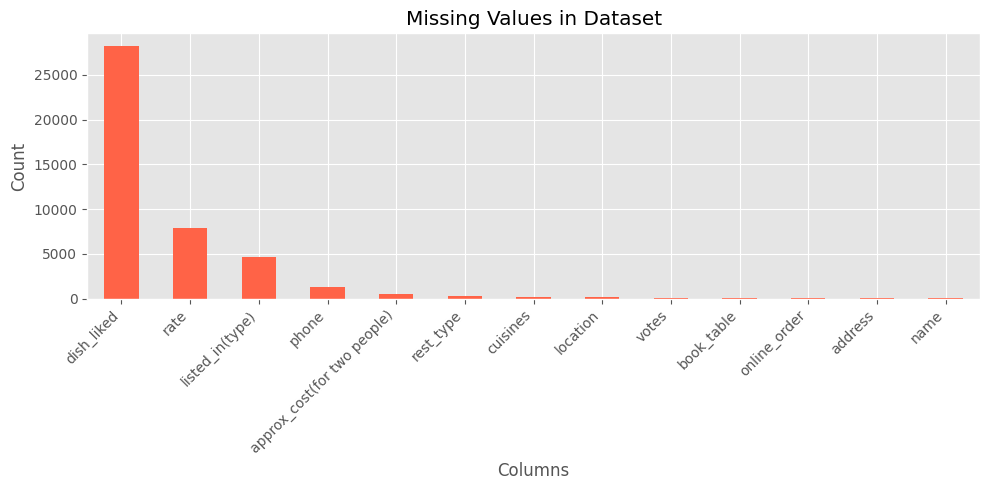

In [29]:
plt.figure(figsize=(10,5))

missing[missing > 0].sort_values(ascending=False).plot(
    kind='bar',
    color='tomato'
)

plt.title("Missing Values in Dataset")
plt.xlabel("Columns")
plt.ylabel("Count")

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()

Observation
The dataset contains missing values in a few columns.
Fields such as dish_liked, phone, and rest_type have missing entries.
These missing values will be handled before performing detailed analysis.

In [30]:
# Check duplicate records
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 15703


In [31]:
# Convert rating to numeric
df['rate'] = df['rate'].astype(str)

# Remove '/5' if present
df['rate'] = df['rate'].str.replace('/5', '', regex=False)

# Convert to numeric
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

print(df['rate'].head())

0    4.1
1    4.1
2    3.8
3    3.7
4    3.8
Name: rate, dtype: float64


In [32]:
# Remove commas from cost column
df['approx_cost(for two people)'] = (
    df['approx_cost(for two people)']
    .astype(str)
    .str.replace(',', '', regex=False)
)

df['approx_cost(for two people)'] = pd.to_numeric(
    df['approx_cost(for two people)'],
    errors='coerce'
)

print(df['approx_cost(for two people)'].head())

0    800.0
1    800.0
2    800.0
3    300.0
4    600.0
Name: approx_cost(for two people), dtype: float64


In [33]:
# Fill missing values
df['dish_liked'] = df['dish_liked'].fillna('Not Available')
df['phone'] = df['phone'].fillna('Not Available')
df['rest_type'] = df['rest_type'].fillna('Unknown')
df['cuisines'] = df['cuisines'].fillna('Unknown')

In [34]:
print(df.isnull().sum())

address                           17
name                              16
online_order                      19
book_table                        58
rate                           14587
votes                             78
phone                              0
location                         126
rest_type                          0
dish_liked                         0
cuisines                           0
approx_cost(for two people)     4881
listed_in(type)                 4610
dtype: int64


Observation

Duplicate records were removed from the dataset.
The rate column was converted into numeric format.
The approximate cost column was cleaned and converted into numeric values.
Missing values in important text columns were handled to improve data quality.

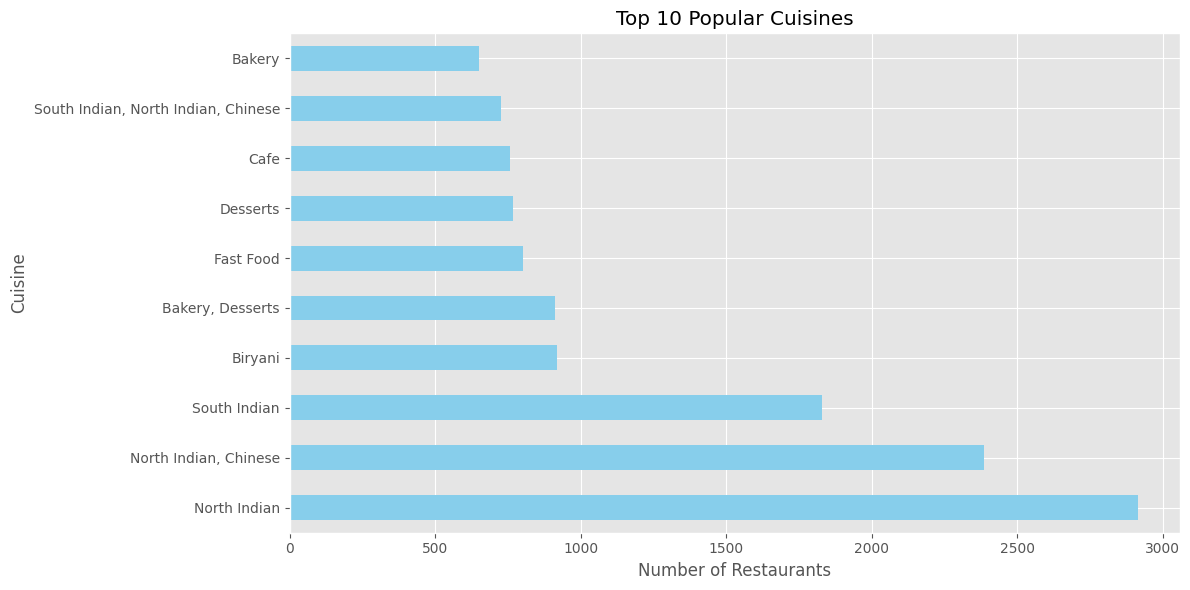

In [35]:
plt.figure(figsize=(12,6))

top_cuisines = df['cuisines'].value_counts().head(10)

top_cuisines.plot(kind='barh', color='skyblue')

plt.title("Top 10 Popular Cuisines")
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine")

plt.tight_layout()
plt.show()

Observation

North Indian cuisine is the most popular cuisine.
Chinese, South Indian, and Fast Food are also widely served.
Restaurants mainly focus on cuisines with high customer demand.

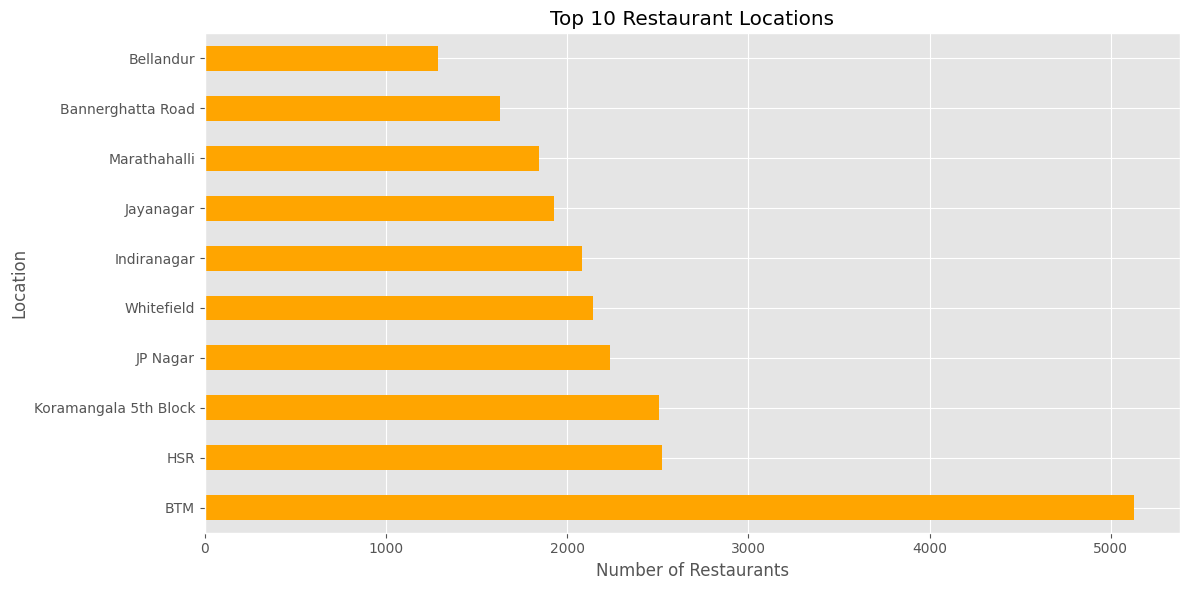

In [36]:
plt.figure(figsize=(12,6))

top_locations = df['location'].value_counts().head(10)

top_locations.plot(kind='barh', color='orange')

plt.title("Top 10 Restaurant Locations")
plt.xlabel("Number of Restaurants")
plt.ylabel("Location")

plt.tight_layout()
plt.show()

Observation

BTM, Koramangala, and HSR are among the major restaurant hotspots.
These areas have a high concentration of restaurants, indicating strong customer demand.

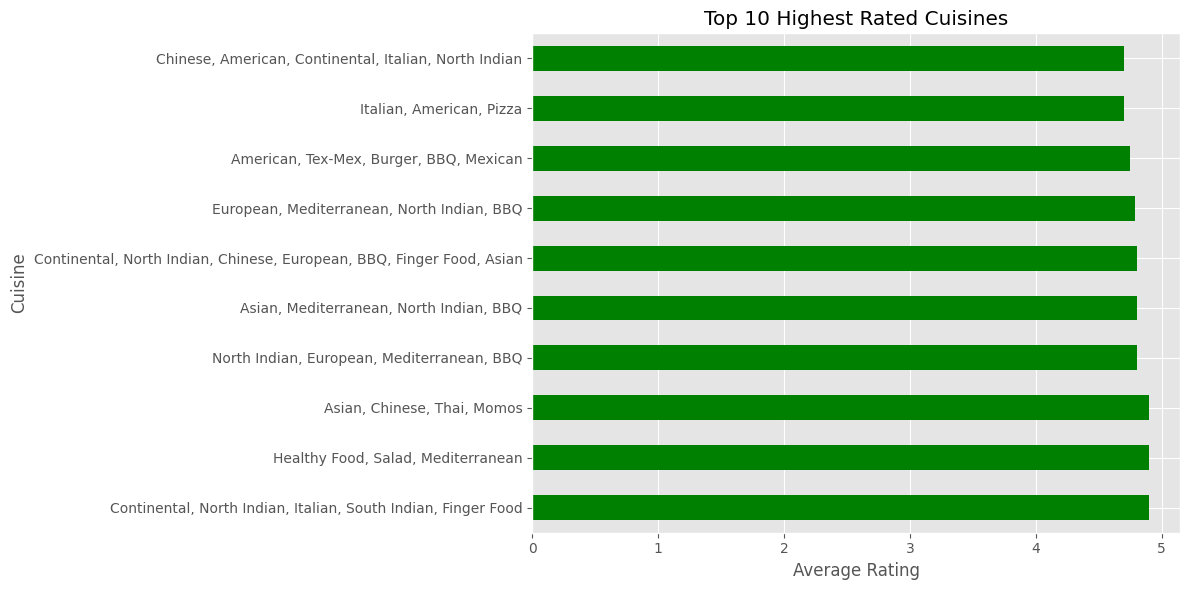

In [37]:
top_rating = (
    df.groupby('cuisines')['rate']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))

top_rating.plot(kind='barh', color='green')

plt.title("Top 10 Highest Rated Cuisines")
plt.xlabel("Average Rating")
plt.ylabel("Cuisine")

plt.tight_layout()
plt.show()

Observation

Some cuisines consistently receive higher customer ratings.
This suggests that cuisine type influences customer satisfaction.

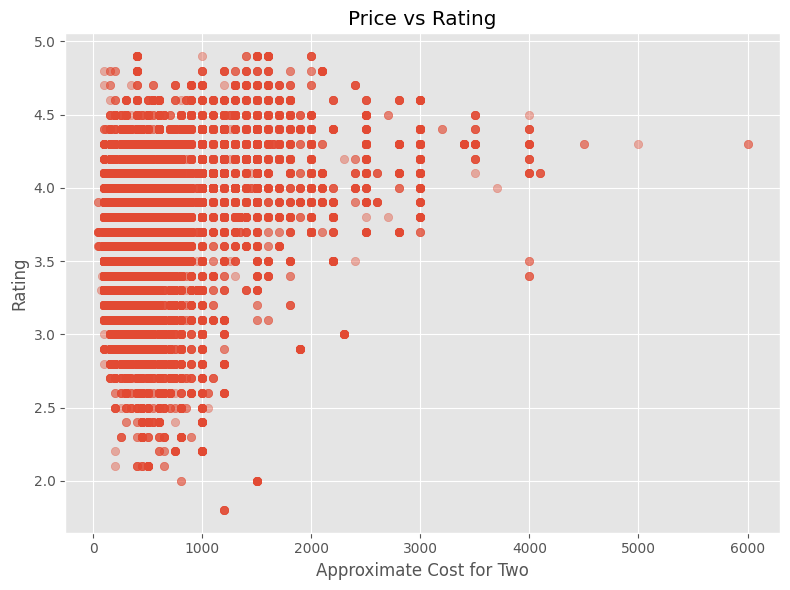

In [38]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['approx_cost(for two people)'],
    df['rate'],
    alpha=0.4
)

plt.title("Price vs Rating")
plt.xlabel("Approximate Cost for Two")
plt.ylabel("Rating")

plt.tight_layout()
plt.show()

Observation

Higher-priced restaurants do not always receive higher ratings.
Customer satisfaction depends on service and food quality rather than price alone.

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_df = df[['rate', 'votes', 'approx_cost(for two people)']]

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

ValueError: could not convert string to float: ' no outdoor seating.\\nFood is delicious'

<Figure size 800x600 with 0 Axes>

In [ ]:
print(df[['rate', 'votes', 'approx_cost(for two people)']].dtypes)

In [ ]:
df[['rate', 'votes', 'approx_cost(for two people)']].head()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert numeric columns safely
df['rate'] = pd.to_numeric(df['rate'], errors='coerce')
df['votes'] = pd.to_numeric(df['votes'], errors='coerce')
df['approx_cost(for two people)'] = pd.to_numeric(
    df['approx_cost(for two people)'],
    errors='coerce'
)

numeric_df = df[['rate', 'votes', 'approx_cost(for two people)']].dropna()

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [40]:
print(df[['rate','votes','approx_cost(for two people)']].head(20))

    rate                                    votes  approx_cost(for two people)
0    4.1                                      775                        800.0
1    4.1                                      787                        800.0
2    3.8                                      918                        800.0
3    3.7                                       88                        300.0
4    3.8                                      166                        600.0
5    3.8                                      286                        600.0
6    3.6                                        8                        800.0
7    4.6                                     2556                        600.0
8    4.0                                      324                        700.0
9    NaN   no outdoor seating.\nFood is delicious                          NaN
10   4.2                                      504                        550.0
11   4.1                                      402   

In [ ]:
!pip install wordcloud

In [41]:
print(df.columns.tolist())

['address', 'name', 'online_order', 'book_table', 'rate', 'votes', 'phone', 'location', 'rest_type', 'dish_liked', 'cuisines', 'approx_cost(for two people)', 'listed_in(type)']


In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(df['cuisines'].dropna().astype(str))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white',
    colormap='viridis'
).generate(text)

plt.figure(figsize=(14,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Most Popular Cuisines WordCloud")
plt.show()

In [42]:
df.head()

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800.0,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800.0,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800.0,Buffet
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300.0,Buffet
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600.0,Buffet


In [43]:
df.iloc[41696]

,41696
address,was an unpleasant experience.\nI did try Mang...
name,never had it before.')
online_order,('Rated 1.0'
book_table,"""""RATED\n I had been tonight with my parents..."
rate,NaN
votes,Cocktail Idli and Husky Watermelon Lemonade.\...
phone,it's unavailable. It was frustrating.\n\nI am...
location,('Rated 5.0'
rest_type,'RATED\n We visited this place at snack time
dish_liked,so could not try the different interesting th...


Observation

The WordCloud highlights the cuisines that appear most frequently in the dataset.
North Indian, Chinese, South Indian, Fast Food, and Cafe are among the most dominant cuisines.
These cuisines represent the highest customer demand across restaurants.

In [44]:
df = pd.read_csv('/content/zomato.csv')

print(df.head())
print(df.shape)

                                             address                   name  \
0  942, 21st Main Road, 2nd Stage, Banashankari, ...                  Jalsa   
1  2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...         Spice Elephant   
2  1112, Next to KIMS Medical College, 17th Cross...        San Churro Cafe   
3  1st Floor, Annakuteera, 3rd Stage, Banashankar...  Addhuri Udupi Bhojana   
4  10, 3rd Floor, Lakshmi Associates, Gandhi Baza...          Grand Village   

  online_order book_table   rate votes                             phone  \
0          Yes        Yes  4.1/5   775    080 42297555\r\n+91 9743772233   
1          Yes         No  4.1/5   787                      080 41714161   
2          Yes         No  3.8/5   918                    +91 9663487993   
3           No         No  3.7/5    88                    +91 9620009302   
4           No         No  3.8/5   166  +91 8026612447\r\n+91 9901210005   

       location            rest_type  \
0  Banashankari        Casua

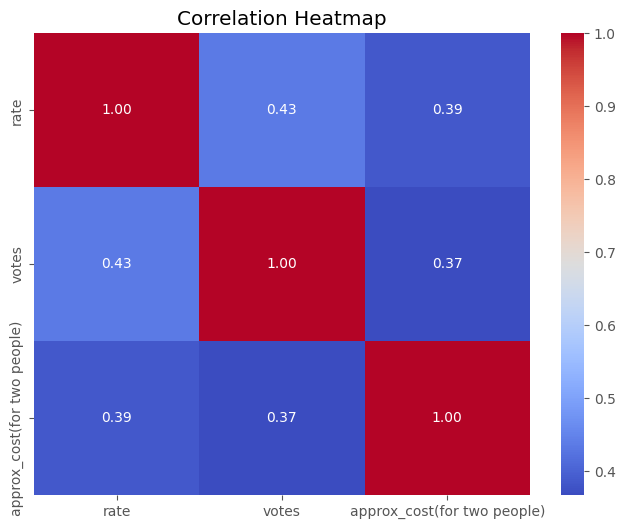

In [45]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df['rate'] = (
    df['rate']
    .astype(str)
    .str.replace('/5', '', regex=False)
)

df['rate'] = pd.to_numeric(df['rate'], errors='coerce')

df['votes'] = pd.to_numeric(df['votes'], errors='coerce')

df['approx_cost(for two people)'] = (
    df['approx_cost(for two people)']
    .astype(str)
    .str.replace(',', '', regex=False)
)

df['approx_cost(for two people)'] = pd.to_numeric(
    df['approx_cost(for two people)'],
    errors='coerce'
)

numeric_df = df[['rate', 'votes', 'approx_cost(for two people)']].dropna()

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

📌 Key Findings
The dataset contains restaurants from multiple locations with different cuisines and pricing.
North Indian, Chinese, South Indian, and Fast Food are the most popular cuisines.
Areas like BTM, Koramangala, and HSR have the highest concentration of restaurants.
Restaurant ratings show a stronger relationship with customer votes than with pricing.
Most restaurants support online ordering, while comparatively fewer offer table booking.
📌 Recommendations for Alfido Tech (InternSpark Requirement)
Partner with highly rated restaurants to improve customer trust and platform quality.
Promote popular cuisines such as North Indian, Chinese, and South Indian through featured campaigns and recommendations.
Increase marketing efforts in restaurant hotspots like BTM, Koramangala, and HSR to maximize customer engagement.
Recommend restaurants based on ratings and customer votes instead of relying only on price.
Encourage restaurants to enable online ordering and table booking, as these features improve user convenience and platform engagement.
📌 Conclusion

This project analyzed the Zomato restaurant dataset using data cleaning, exploratory data analysis, and visualizations. The analysis identified popular cuisines, restaurant hotspots, pricing patterns, customer ratings, and online ordering trends. Heatmaps and WordCloud visualizations provided additional insights into relationships between different variables. Based on these findings, several business recommendations were proposed that can help an Alfido Tech–style platform improve customer satisfaction, strengthen restaurant partnerships, and optimize marketing strategies.